<a href="https://colab.research.google.com/github/TingyuZhao19/MSSP6070/blob/main/WeeklyModules/Week08/PARTICIPATION%20ACTIVITY%20Week%208.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [67]:
from pathlib import Path
import pandas as pd

path = Path("/content/drive/MyDrive/MSSP607/Modules/Week08/InternetSales.csv")
df = pd.read_csv(path, encoding='latin-1', low_memory=False)
display(df.head())

,ID,CustomerKey,GeographyKey,City,CountryRegionCode,EnglishCountryRegionName,CustomerAlternateKey,Title,FirstName,MiddleName,...,ProductStandardCost,TotalProductCost,SalesAmount,TaxAmt,Freight,CarrierTrackingNumber,CustomerPONumber,OrderDate,DueDate,ShipDate
0,0,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1912.1544,1912.1544,3399.99,271.9992,84.9998,NaN,NaN,1/19/2011,1/31/2011,1/26/2011
1,1,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1265.6195,1265.6195,2319.99,185.5992,57.9998,NaN,NaN,1/18/2013,1/30/2013,1/25/2013
2,2,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,8.2205,8.2205,21.98,1.7584,0.5495,NaN,NaN,1/18/2013,1/30/2013,1/25/2013
3,3,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1481.9379,1481.9379,2384.07,190.7256,59.6018,NaN,NaN,5/3/2013,5/15/2013,5/10/2013
4,4,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,10.8423,10.8423,28.99,2.3192,0.7248,NaN,NaN,5/3/2013,5/15/2013,5/10/2013


## Prepare data

### Subtask:
Aggregate the sales data by date and ensure it is in a suitable format for time series forecasting by selecting relevant columns, converting the date column to datetime objects, setting it as the index, resampling to daily frequency, and filling missing values.


In [68]:
df_agg = df[['OrderDate', 'SalesAmount']].copy()
df_agg['OrderDate'] = pd.to_datetime(df_agg['OrderDate'])
df_agg = df_agg.set_index('OrderDate')
df_agg = df_agg.resample('D').sum()
df_agg = df_agg.fillna(0)
display(df_agg.head())

,SalesAmount
OrderDate,
2010-12-29,14477.3382
2010-12-30,13931.5200
2010-12-31,15012.1782
2011-01-01,7156.5400
2011-01-02,15012.1782


## Visualize data

### Subtask:
Create a time series plot of the aggregated sales data to visualize the trend and patterns.


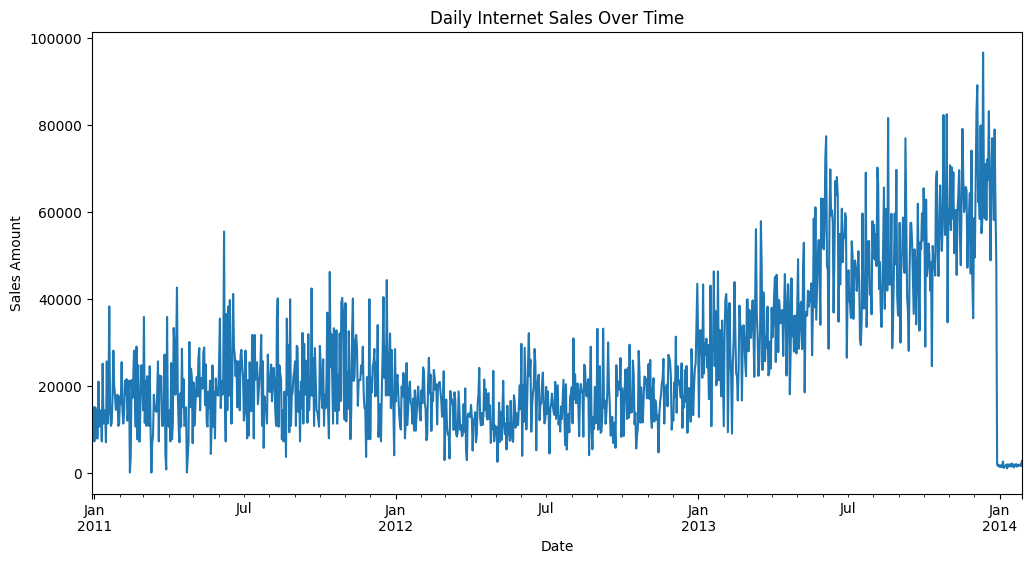

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
df_agg['SalesAmount'].plot()
plt.title('Daily Internet Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales Amount')
plt.show()

## Choose and train model

### Subtask:
Based on the observed seasonality and trend in the historical data plot, the Prophet model is a suitable choice. Import the necessary libraries and prepare the data in the format required by Prophet.

In [70]:
!pip install cmdstanpy==1.0.4

In [71]:
!pip install prophet

In [72]:
from prophet import Prophet

# Prepare data for Prophet (rename columns to 'ds' and 'y')
prophet_df = df_agg.reset_index().rename(columns={'OrderDate': 'ds', 'SalesAmount': 'y'})

# Initialize and fit the Prophet model with specified seasonality
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(prophet_df)

DEBUG:cmdstanpy:input tempfile: /tmp/tmpfx14ahcy/2bhqde3q.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpfx14ahcy/zpaaja15.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=42758', 'data', 'file=/tmp/tmpfx14ahcy/2bhqde3q.json', 'init=/tmp/tmpfx14ahcy/zpaaja15.json', 'output', 'file=/tmp/tmpfx14ahcy/prophet_model5s87ycnw/prophet_model-20251029213608.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
21:36:08 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
21:36:08 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


## Forecast sales

### Subtask:
Generate future dataframe for the next five years and predict the sales using the trained Prophet model.


In [73]:
# Generate future dates for the next 5 years (5 * 365 days)
future_periods = 5 * 365
future = model.make_future_dataframe(periods=future_periods)

# Predict the sales using the trained Prophet model
forecast = model.predict(future)

In [74]:
# Keep only future rows from forecast
future_only = forecast[forecast['ds'] > df_agg.index[-1]].copy()

# Filter for full calendar years within the 5-year forecast period
start_year = future_only['ds'].min().year + 1
end_year = start_year + 4
full_years_forecast = future_only[(future_only['ds'].dt.year >= start_year) & (future_only['ds'].dt.year <= end_year)].copy()

# Roll up to yearly totals for the next 5 full calendar years
full_years_forecast['year'] = full_years_forecast['ds'].dt.year
yearly_forecast = full_years_forecast.groupby('year', as_index=False)['yhat'].sum()

display(yearly_forecast)

,year,yhat
0,2015,1.264753e+07
1,2016,1.065869e+07
2,2017,8.624480e+06
3,2018,6.615557e+06
4,2019,9.015004e+04


## Visualize forecast

Visualize the historical data and the forecast using the Prophet plot function.


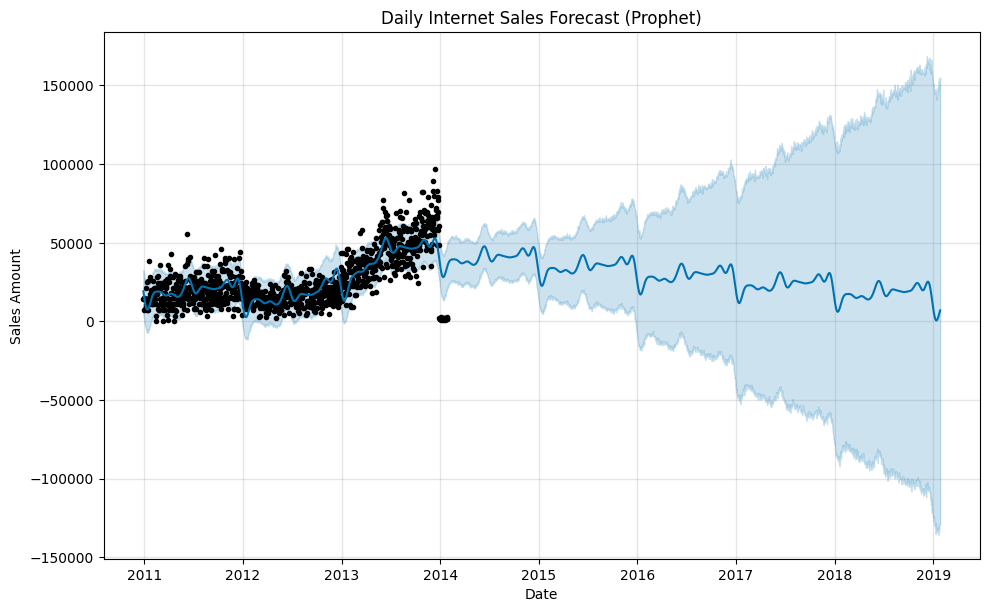

In [75]:
# Visualize the historical data and the forecast using the Prophet plot function.
fig1 = model.plot(forecast)
plt.title('Daily Internet Sales Forecast (Prophet)')
plt.xlabel('Date')
plt.ylabel('Sales Amount')
plt.show()

In [76]:
# Calculate total sales for each product
product_sales = df.groupby('EnglishProductName')['SalesAmount'].sum()

# Find the product with the maximum sales
most_sold_product = product_sales.idxmax()
max_sales_amount = product_sales.max()

print(f"The product that generated the most sales is '{most_sold_product}' with a total sales amount of ${max_sales_amount:.2f}.")

The product that generated the most sales is 'Mountain-200 Black, 46' with a total sales amount of $1373469.55.


In [77]:
prod_totals = (df.groupby('EnglishProductName')['SalesAmount']
                 .sum()
                 .sort_values(ascending=False))
top_product = prod_totals.index[0]
top_total   = prod_totals.iloc[0]

print(f"Top product by TOTAL SalesAmount: {top_product} (total={top_total:,.2f})")
prod_totals.head(10)

Top product by TOTAL SalesAmount: Mountain-200 Black, 46 (total=1,373,469.55)


,SalesAmount
EnglishProductName,
"Mountain-200 Black, 46",1.373470e+06
"Mountain-200 Black, 42",1.363142e+06
"Mountain-200 Silver, 38",1.339463e+06
"Mountain-200 Silver, 46",1.301100e+06
"Mountain-200 Black, 38",1.294866e+06
"Mountain-200 Silver, 42",1.257435e+06
"Road-150 Red, 48",1.205877e+06
"Road-150 Red, 62",1.202299e+06
"Road-150 Red, 52",1.080638e+06
